# Padronizacao dos graficos - Counting Sort

Este notebook usa os CSVs gerados pelos benchmarks em Python e Rust para analisar o Counting Sort apos a revisao metodologica do projeto.

A abordagem atual fixa `n = 1.000.000` e varia `k`, pois o Counting Sort nao muda de melhor, medio e pior caso pela ordem inicial do vetor. O custo teorico usado e `T(n, k) = n + k`.

Os graficos exibem media e desvio padrao das 30 execucoes. Para evitar excesso de linhas, o comparativo final destaca somente o pior cenario (`k = 100.000.000`).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["figure.dpi"] = 120


def localizar_raiz_projeto():
    current_dir = Path.cwd().resolve()
    for candidate in [current_dir, *current_dir.parents]:
        if (candidate / "rust" / "Cargo.toml").exists() and (candidate / "python").exists():
            return candidate
    raise FileNotFoundError("Nao foi possivel localizar a raiz do projeto.")


project_root = localizar_raiz_projeto()
analysis_dir = project_root / "analise"
data_dir = analysis_dir / "dados"
tables_dir = analysis_dir / "tabelas"
plots_dir = analysis_dir / "graficos"

tables_dir.mkdir(exist_ok=True)
plots_dir.mkdir(exist_ok=True)

python_csv = data_dir / "resultados_python.csv"
rust_csv = data_dir / "resultados_rust.csv"
input_plan_csv = data_dir / "entradas_benchmark.csv"

print(f"Raiz do projeto: {project_root}")
print(f"Lendo: {python_csv}")
print(f"Lendo: {rust_csv}")
print(f"Plano de entradas: {input_plan_csv}")

Raiz do projeto: C:\Users\gusta\OneDrive\Documentos\Equipe7_TCB
Lendo: C:\Users\gusta\OneDrive\Documentos\Equipe7_TCB\analise\dados\resultados_python.csv
Lendo: C:\Users\gusta\OneDrive\Documentos\Equipe7_TCB\analise\dados\resultados_rust.csv
Plano de entradas: C:\Users\gusta\OneDrive\Documentos\Equipe7_TCB\analise\dados\entradas_benchmark.csv


In [2]:
df_python = pd.read_csv(python_csv)
df_rust = pd.read_csv(rust_csv)

input_plan = pd.read_csv(input_plan_csv)
df = pd.concat([df_python, df_rust], ignore_index=True)
df["ordenado"] = df["ordenado"].astype(str).str.lower().map({"true": True, "false": False})
df["complexidade_teorica"] = df["n"] + df["k"]

ordem_casos = ["melhor", "medio", "pior"]
ordem_linguagens = ["python", "rust"]
df["caso"] = pd.Categorical(df["caso"], categories=ordem_casos, ordered=True)
df["linguagem"] = pd.Categorical(df["linguagem"], categories=ordem_linguagens, ordered=True)

assert df["ordenado"].all(), "Ha pelo menos uma execucao com saida nao ordenada."
assert len(df_python) == len(df_rust), "Python e Rust devem ter a mesma quantidade de execucoes."
assert df_python[["caso", "n", "k", "execucao", "seed"]].equals(df_rust[["caso", "n", "k", "execucao", "seed"]]), "Python e Rust nao usaram o mesmo plano de entradas."

comparacao_checksums = df_python[["caso", "n", "k", "execucao", "seed", "checksum_entrada"]].copy()
comparacao_checksums = comparacao_checksums.rename(columns={"checksum_entrada": "checksum_python"})
comparacao_checksums["checksum_rust"] = df_rust["checksum_entrada"].values
comparacao_checksums["checksum_igual"] = comparacao_checksums["checksum_python"] == comparacao_checksums["checksum_rust"]

total_checksums = len(comparacao_checksums)
checksums_corretos = int(comparacao_checksums["checksum_igual"].sum())
percentual_checksums_corretos = checksums_corretos / total_checksums * 100

resumo_checksums = pd.DataFrame([
    {
        "total_execucoes_comparadas": total_checksums,
        "checksums_iguais": checksums_corretos,
        "checksums_diferentes": total_checksums - checksums_corretos,
        "percentual_checksums_iguais": percentual_checksums_corretos,
    }
])
resumo_checksums.to_csv(tables_dir / "verificacao_checksums.csv", index=False)
comparacao_checksums.to_csv(tables_dir / "comparacao_checksums_entradas.csv", index=False)

print(f"Checksums iguais: {checksums_corretos}/{total_checksums} ({percentual_checksums_corretos:.2f}%)")
assert comparacao_checksums["checksum_igual"].all(), "Python e Rust nao reconstruiram as mesmas entradas."

df.head()

Checksums iguais: 90/90 (100.00%)


,linguagem,caso,tamanho_label,n,k,execucao,seed,checksum_entrada,tempo_segundos,ordenado,complexidade_teorica
0,python,melhor,n_fixo_k_pequeno,1000000,100,1,1010085,25246267278706,0.064019,True,1000100
1,python,melhor,n_fixo_k_pequeno,1000000,100,2,1010086,25211915143553,0.062200,True,1000100
2,python,melhor,n_fixo_k_pequeno,1000000,100,3,1010087,25251320391636,0.062882,True,1000100
3,python,melhor,n_fixo_k_pequeno,1000000,100,4,1010088,25238303012451,0.062303,True,1000100
4,python,melhor,n_fixo_k_pequeno,1000000,100,5,1010089,25261978555722,0.062235,True,1000100


In [3]:
resumo = (
    df.groupby(["linguagem", "caso", "tamanho_label", "n", "k"], observed=True)
    .agg(
        media_segundos=("tempo_segundos", "mean"),
        desvio_padrao_segundos=("tempo_segundos", "std"),
        minimo_segundos=("tempo_segundos", "min"),
        maximo_segundos=("tempo_segundos", "max"),
        execucoes=("tempo_segundos", "count"),
        complexidade_teorica=("complexidade_teorica", "first"),
    )
    .reset_index()
)

resumo["coeficiente_variacao"] = resumo["desvio_padrao_segundos"] / resumo["media_segundos"]
resumo.to_csv(tables_dir / "resumo_tempos.csv", index=False)
input_plan.to_csv(tables_dir / "plano_entradas_benchmark.csv", index=False)
resumo

,linguagem,caso,tamanho_label,n,k,media_segundos,desvio_padrao_segundos,minimo_segundos,maximo_segundos,execucoes,complexidade_teorica,coeficiente_variacao
0,python,melhor,n_fixo_k_pequeno,1000000,100,0.061852,0.002095,0.058378,0.067197,30,1000100,0.033875
1,python,medio,n_fixo_k_igual_n,1000000,1000000,0.211211,0.036153,0.178360,0.314883,30,2000000,0.171170
2,python,pior,n_fixo_k_grande,1000000,100000000,9.801307,0.506056,9.576615,12.240949,30,101000000,0.051631
3,rust,melhor,n_fixo_k_pequeno,1000000,100,0.001377,0.000327,0.000883,0.002185,30,1000100,0.237412
4,rust,medio,n_fixo_k_igual_n,1000000,1000000,0.011865,0.002052,0.009720,0.019787,30,2000000,0.172975
5,rust,pior,n_fixo_k_grande,1000000,100000000,0.308519,0.012682,0.296591,0.354157,30,101000000,0.041105


In [4]:
def salvar_figura(nome_arquivo):
    path = plots_dir / nome_arquivo
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Grafico salvo em: {path}")


def plot_com_desvio(data, x_col, y_col, err_col, group_col, title, xlabel, ylabel, filename, log_x=False, log_y=False):
    fig, ax = plt.subplots()
    palette = dict(zip(ordem_linguagens, sns.color_palette("Set2", n_colors=len(ordem_linguagens))))

    for language in ordem_linguagens:
        subset = data[data[group_col].astype(str) == language].sort_values(x_col)
        ax.errorbar(
            subset[x_col],
            subset[y_col],
            yerr=subset[err_col],
            marker="o",
            linewidth=2,
            capsize=5,
            label=language.capitalize(),
            color=palette[language],
        )

    if log_x:
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(title="Linguagem")
    salvar_figura(filename)

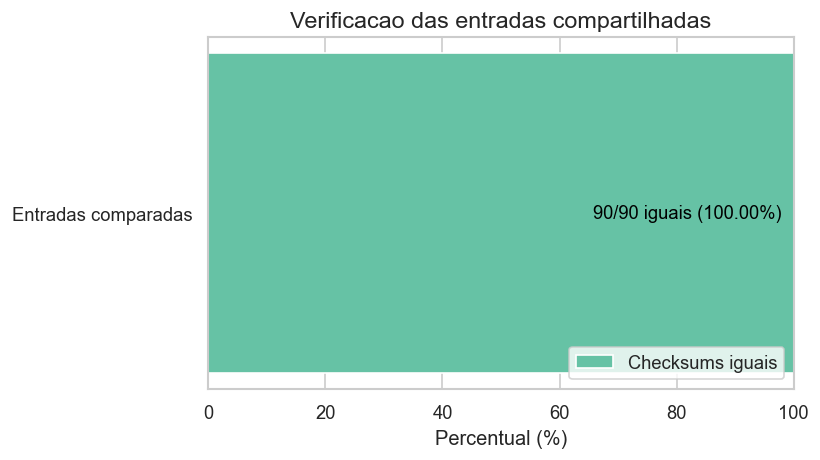

Grafico salvo em: C:\Users\gusta\OneDrive\Documentos\Equipe7_TCB\analise\graficos\00_verificacao_checksums.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
percentual_diferentes = 100 - percentual_checksums_corretos
ax.barh(
    ["Entradas comparadas"],
    [percentual_checksums_corretos],
    color=sns.color_palette("Set2", n_colors=1),
    label="Checksums iguais",
)
if percentual_diferentes > 0:
    ax.barh(
        ["Entradas comparadas"],
        [percentual_diferentes],
        left=[percentual_checksums_corretos],
        color="#d95f02",
        label="Checksums diferentes",
    )

ax.set_xlim(0, 100)
ax.set_xlabel("Percentual (%)")
ax.set_title("Verificacao das entradas compartilhadas")
ax.text(
    min(percentual_checksums_corretos, 98),
    0,
    f"{checksums_corretos}/{total_checksums} iguais ({percentual_checksums_corretos:.2f}%)",
    va="center",
    ha="right",
    color="black",
    fontsize=11,
)
ax.legend(loc="lower right")
salvar_figura("00_verificacao_checksums.png")

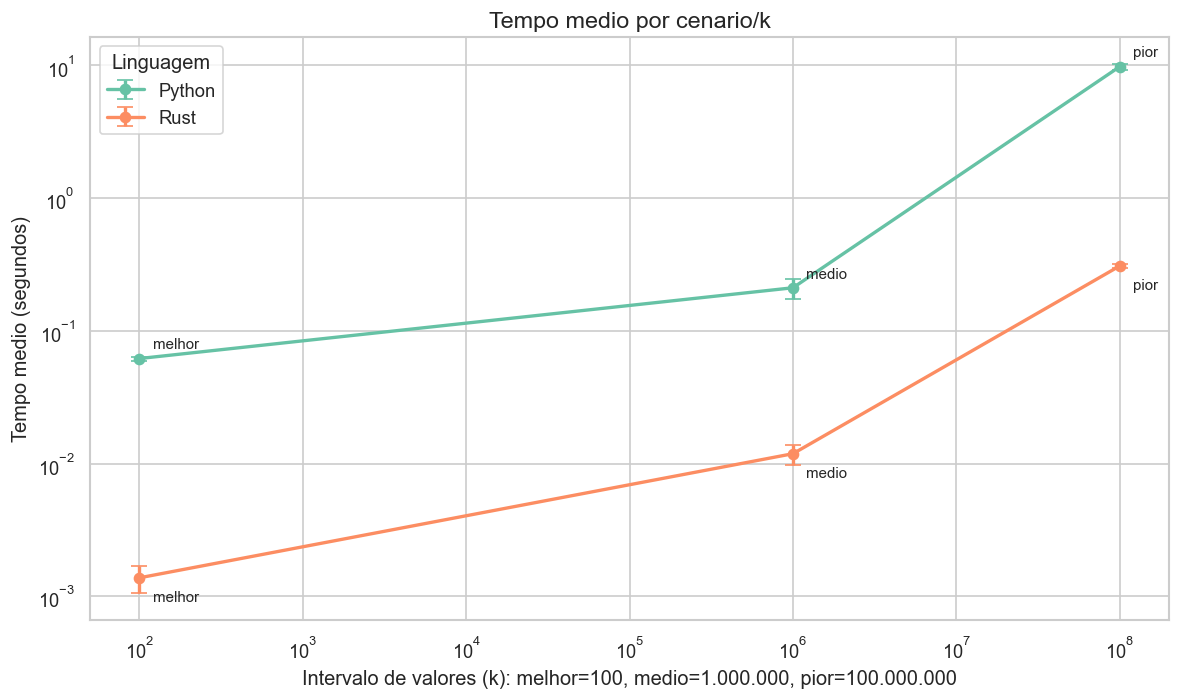

Grafico salvo em: C:\Users\gusta\OneDrive\Documentos\Equipe7_TCB\analise\graficos\01_tempo_por_k_com_desvio_log.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = dict(zip(ordem_linguagens, sns.color_palette("Set2", n_colors=len(ordem_linguagens))))

for language in ordem_linguagens:
    subset = resumo[resumo["linguagem"].astype(str) == language].sort_values("k")
    ax.errorbar(
        subset["k"],
        subset["media_segundos"],
        yerr=subset["desvio_padrao_segundos"],
        marker="o",
        linewidth=2,
        capsize=5,
        label=language.capitalize(),
        color=palette[language],
    )

    for _, row in subset.iterrows():
        ax.annotate(
            str(row["caso"]),
            (row["k"], row["media_segundos"]),
            textcoords="offset points",
            xytext=(8, 6 if language == "python" else -14),
            fontsize=9,
        )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Tempo medio por cenario/k")
ax.set_xlabel("Intervalo de valores (k): melhor=100, medio=1.000.000, pior=100.000.000")
ax.set_ylabel("Tempo medio (segundos)")
ax.legend(title="Linguagem")
salvar_figura("01_tempo_por_k_com_desvio_log.png")

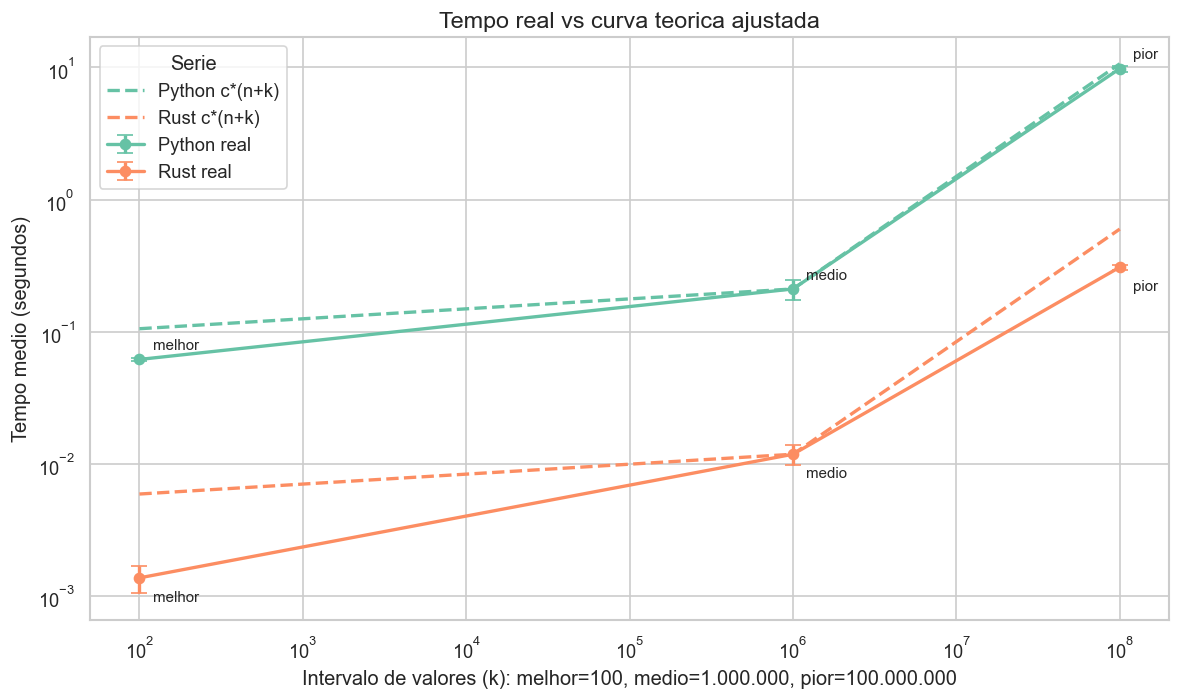

Grafico salvo em: C:\Users\gusta\OneDrive\Documentos\Equipe7_TCB\analise\graficos\02_real_vs_teorico_por_k_log.png


In [7]:
teorico = resumo.copy()
teorico["tempo_teorico_ajustado"] = np.nan

for language in ordem_linguagens:
    subset = teorico[teorico["linguagem"].astype(str) == language]
    reference = subset[subset["caso"].astype(str) == "medio"].iloc[0]
    c = reference["media_segundos"] / reference["complexidade_teorica"]
    teorico.loc[subset.index, "tempo_teorico_ajustado"] = subset["complexidade_teorica"] * c

resumo_com_teoria = teorico.copy()
resumo_com_teoria.to_csv(tables_dir / "resumo_tempos_com_teoria.csv", index=False)

fig, ax = plt.subplots()
palette = dict(zip(ordem_linguagens, sns.color_palette("Set2", n_colors=len(ordem_linguagens))))

for language in ordem_linguagens:
    subset = teorico[teorico["linguagem"].astype(str) == language].sort_values("k")
    ax.errorbar(
        subset["k"],
        subset["media_segundos"],
        yerr=subset["desvio_padrao_segundos"],
        marker="o",
        linewidth=2,
        capsize=5,
        label=f"{language.capitalize()} real",
        color=palette[language],
    )
    ax.plot(
        subset["k"],
        subset["tempo_teorico_ajustado"],
        linestyle="--",
        linewidth=2,
        label=f"{language.capitalize()} c*(n+k)",
        color=palette[language],
    )

ax.set_xscale("log")
ax.set_yscale("log")
for _, row in teorico.iterrows():
    ax.annotate(
        str(row["caso"]),
        (row["k"], row["media_segundos"]),
        textcoords="offset points",
        xytext=(8, 6 if str(row["linguagem"]) == "python" else -14),
        fontsize=9,
    )

ax.set_title("Tempo real vs curva teorica ajustada")
ax.set_xlabel("Intervalo de valores (k): melhor=100, medio=1.000.000, pior=100.000.000")
ax.set_ylabel("Tempo medio (segundos)")
ax.legend(title="Serie")
salvar_figura("02_real_vs_teorico_por_k_log.png")

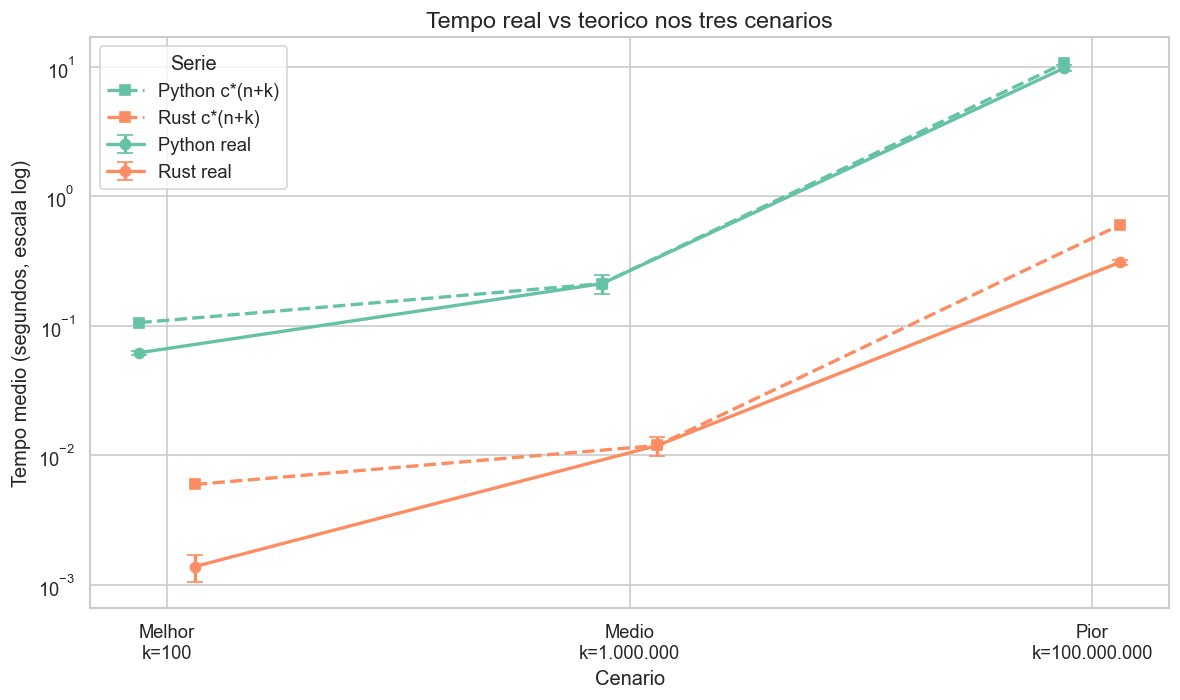

Grafico salvo em: C:\Users\gusta\OneDrive\Documentos\Equipe7_TCB\analise\graficos\03_real_vs_teorico_tres_cenarios.png


In [8]:
cenario_posicao = {"melhor": 0, "medio": 1, "pior": 2}
teorico_casos = teorico.copy()
teorico_casos["cenario_x"] = teorico_casos["caso"].astype(str).map(cenario_posicao)

fig, ax = plt.subplots(figsize=(10, 6))
palette = dict(zip(ordem_linguagens, sns.color_palette("Set2", n_colors=len(ordem_linguagens))))
offsets = {"python": -0.06, "rust": 0.06}

for language in ordem_linguagens:
    subset = teorico_casos[teorico_casos["linguagem"].astype(str) == language].sort_values("cenario_x")
    x = subset["cenario_x"] + offsets[language]

    ax.errorbar(
        x,
        subset["media_segundos"],
        yerr=subset["desvio_padrao_segundos"],
        marker="o",
        linewidth=2,
        capsize=5,
        label=f"{language.capitalize()} real",
        color=palette[language],
    )
    ax.plot(
        x,
        subset["tempo_teorico_ajustado"],
        linestyle="--",
        linewidth=2,
        marker="s",
        label=f"{language.capitalize()} c*(n+k)",
        color=palette[language],
    )

ax.set_xticks(list(cenario_posicao.values()))
ax.set_xticklabels(["Melhor\nk=100", "Medio\nk=1.000.000", "Pior\nk=100.000.000"])
ax.set_yscale("log")
ax.set_title("Tempo real vs teorico nos tres cenarios")
ax.set_xlabel("Cenario")
ax.set_ylabel("Tempo medio (segundos, escala log)")
ax.legend(title="Serie")
salvar_figura("03_real_vs_teorico_tres_cenarios.png")

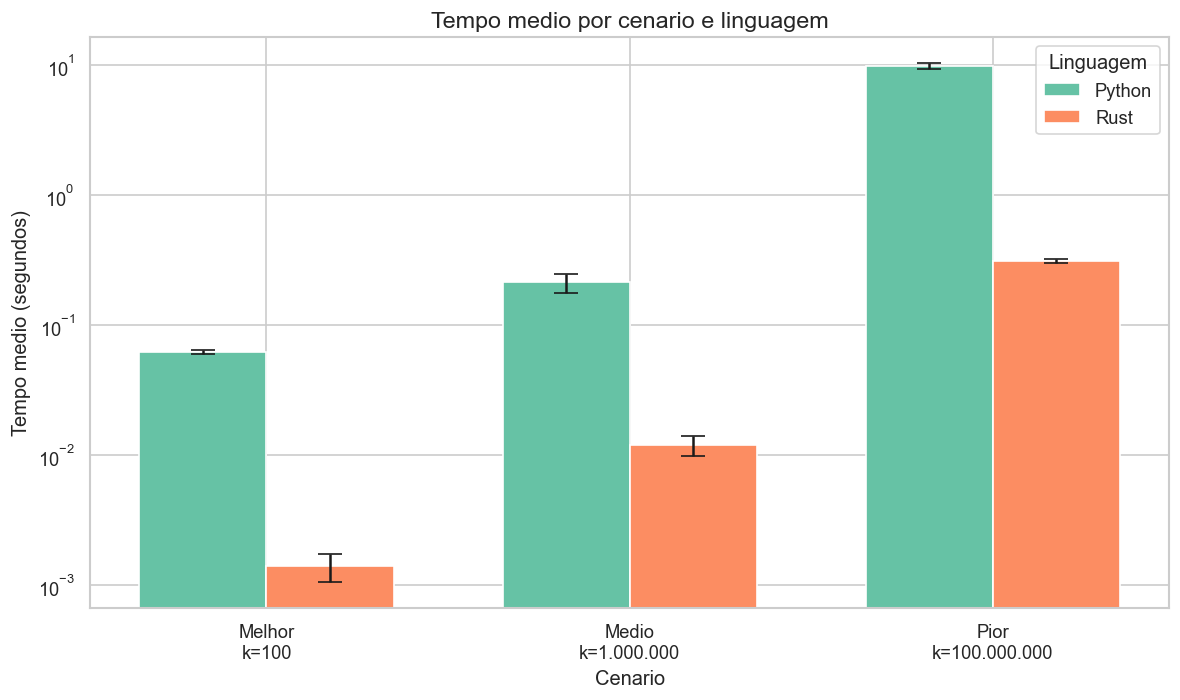

Grafico salvo em: C:\Users\gusta\OneDrive\Documentos\Equipe7_TCB\analise\graficos\04_cenarios_com_desvio.png


In [9]:
resumo_cenarios = resumo.copy().sort_values(["caso", "linguagem"])
resumo_cenarios.to_csv(tables_dir / "resumo_cenarios.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(ordem_casos))
width = 0.35
palette = dict(zip(ordem_linguagens, sns.color_palette("Set2", n_colors=len(ordem_linguagens))))

for index, language in enumerate(ordem_linguagens):
    subset = resumo_cenarios[resumo_cenarios["linguagem"].astype(str) == language].sort_values("caso")
    offset = (index - 0.5) * width
    ax.bar(
        x + offset,
        subset["media_segundos"],
        width,
        yerr=subset["desvio_padrao_segundos"],
        capsize=7,
        label=language.capitalize(),
        color=palette[language],
    )

ax.set_title("Tempo medio por cenario e linguagem")
ax.set_xlabel("Cenario")
ax.set_ylabel("Tempo medio (segundos)")
ax.set_xticks(x)
ax.set_xticklabels(["Melhor\nk=100", "Medio\nk=1.000.000", "Pior\nk=100.000.000"])
ax.set_yscale("log")
ax.legend(title="Linguagem")
salvar_figura("04_cenarios_com_desvio.png")

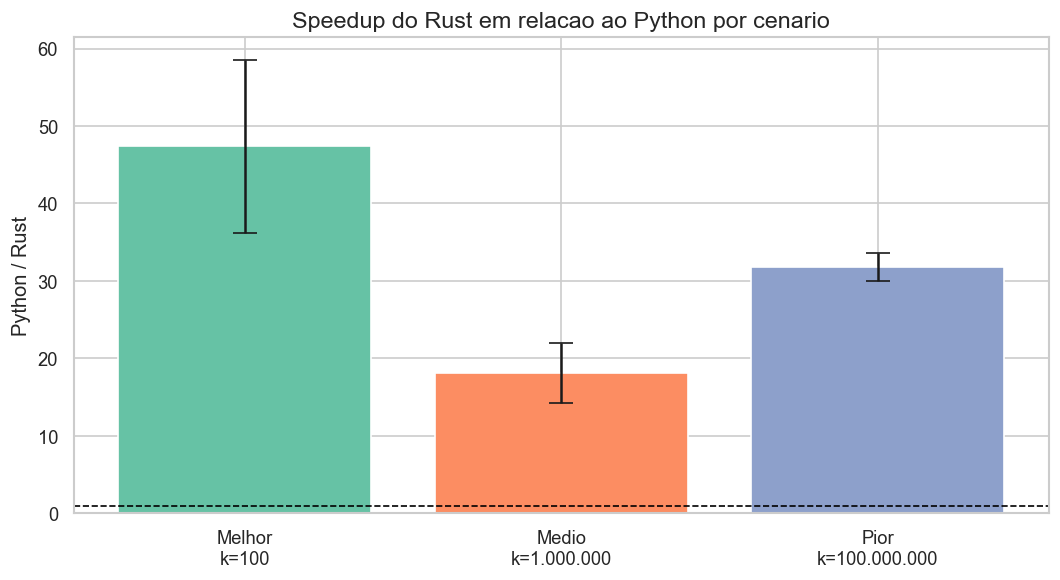

Grafico salvo em: C:\Users\gusta\OneDrive\Documentos\Equipe7_TCB\analise\graficos\05_speedup_rust_vs_python_cenarios.png


,caso,n,k,media_speedup,desvio_padrao_speedup
0,melhor,1000000,100,47.355011,11.166664
1,medio,1000000,1000000,18.157516,3.860376
2,pior,1000000,100000000,31.808460,1.855651


In [10]:
pivot = resumo.pivot_table(index=["caso", "n", "k"], columns="linguagem", values="media_segundos", observed=True).reset_index()
pivot["speedup_rust_vs_python"] = pivot["python"] / pivot["rust"]
pivot.to_csv(tables_dir / "speedup_rust_vs_python.csv", index=False)

speedup_execucoes = df.pivot_table(
    index=["caso", "n", "k", "execucao", "seed"],
    columns="linguagem",
    values="tempo_segundos",
    observed=True,
).reset_index()
speedup_execucoes["speedup_rust_vs_python"] = speedup_execucoes["python"] / speedup_execucoes["rust"]
speedup_resumo = (
    speedup_execucoes.groupby(["caso", "n", "k"], observed=True)
    .agg(
        media_speedup=("speedup_rust_vs_python", "mean"),
        desvio_padrao_speedup=("speedup_rust_vs_python", "std"),
    )
    .reset_index()
)
speedup_resumo.to_csv(tables_dir / "speedup_rust_vs_python_por_execucao.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
speedup_resumo = speedup_resumo.sort_values("caso")
ax.bar(
    ["Melhor\nk=100", "Medio\nk=1.000.000", "Pior\nk=100.000.000"],
    speedup_resumo["media_speedup"],
    yerr=speedup_resumo["desvio_padrao_speedup"],
    capsize=7,
    color=sns.color_palette("Set2", n_colors=len(speedup_resumo)),
)
ax.axhline(1, color="black", linewidth=1, linestyle="--")
ax.set_title("Speedup do Rust em relacao ao Python por cenario")
ax.set_ylabel("Python / Rust")
salvar_figura("05_speedup_rust_vs_python_cenarios.png")

speedup_resumo

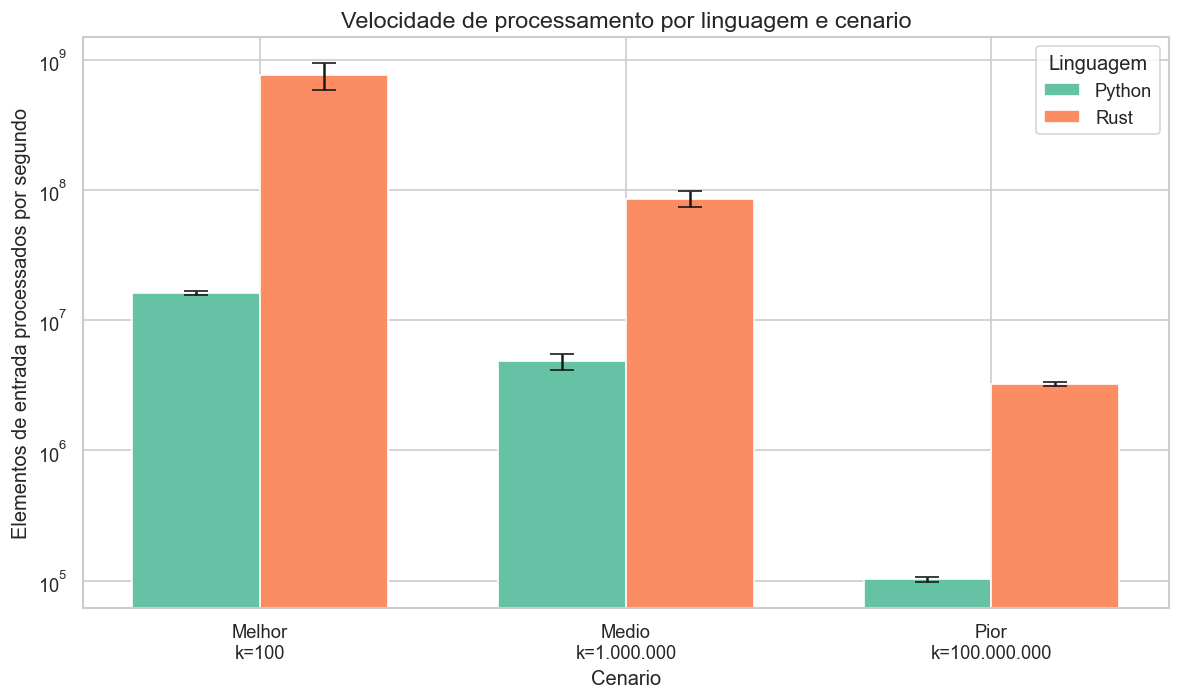

Grafico salvo em: C:\Users\gusta\OneDrive\Documentos\Equipe7_TCB\analise\graficos\06_velocidade_linguagens_cenarios.png


,linguagem,caso,n,k,velocidade_media,desvio_padrao_velocidade
0,python,melhor,1000000,100,1.618532e+07,5.402338e+05
1,python,medio,1000000,1000000,4.844002e+06,6.699838e+05
2,python,pior,1000000,100000000,1.022465e+05,4.403362e+03
3,rust,melhor,1000000,100,7.664301e+08,1.810614e+08
4,rust,medio,1000000,1000000,8.622988e+07,1.201025e+07
5,rust,pior,1000000,100000000,3.246182e+06,1.233641e+05


In [11]:
velocidade_execucoes = df.copy()
velocidade_execucoes["elementos_por_segundo"] = velocidade_execucoes["n"] / velocidade_execucoes["tempo_segundos"]

velocidade_resumo = (
    velocidade_execucoes.groupby(["linguagem", "caso", "n", "k"], observed=True)
    .agg(
        velocidade_media=("elementos_por_segundo", "mean"),
        desvio_padrao_velocidade=("elementos_por_segundo", "std"),
    )
    .reset_index()
)
velocidade_resumo.to_csv(tables_dir / "velocidade_linguagens.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(ordem_casos))
width = 0.35
palette = dict(zip(ordem_linguagens, sns.color_palette("Set2", n_colors=len(ordem_linguagens))))

for index, language in enumerate(ordem_linguagens):
    subset = velocidade_resumo[velocidade_resumo["linguagem"].astype(str) == language].sort_values("caso")
    offset = (index - 0.5) * width
    ax.bar(
        x + offset,
        subset["velocidade_media"],
        width,
        yerr=subset["desvio_padrao_velocidade"],
        capsize=7,
        label=language.capitalize(),
        color=palette[language],
    )

ax.set_title("Velocidade de processamento por linguagem e cenario")
ax.set_xlabel("Cenario")
ax.set_ylabel("Elementos de entrada processados por segundo")
ax.set_xticks(x)
ax.set_xticklabels(["Melhor\nk=100", "Medio\nk=1.000.000", "Pior\nk=100.000.000"])
ax.set_yscale("log")
ax.legend(title="Linguagem")
salvar_figura("06_velocidade_linguagens_cenarios.png")

velocidade_resumo